# 第8周作业：强化学习

### 理解Q学习算法，练习Keras实现 DQN网络  (！注意选用DeepL-3.10服务！)
#### 要求：
1）设计DQN网络，生成policy_net和target_net<BR>
2）调整Q学习算法参数，尝试利用env提供的信息进行reward-shaping策略改进，以提高倒立摆保持时间。

#### 考核办法：
训练100epoch的性能表现,取保持时间最大的一次（评价基准：100-500为成绩考核评定区间，按比例得分）

In [1]:
#首先执行GPU资源分配代码，勿删除。
import GPU
GPU.show()

2026-06-21 12:38:33.381925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-21 12:38:33.411892: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-21 12:38:33.411932: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-21 12:38:33.431379: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-21 12:38:34.408868: W tensorflow/compiler/tf

Sun Jun 21 12:38:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.142                Driver Version: 580.142        CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:02:00.0 Off |                  N/A |
| 30%   29C    P8             23W /  350W |      18MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#选择一个空闲GPU，#0  #1  #2
GPU.alloc(0,1024)


Success.


In [3]:
%matplotlib notebook
import gym
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from itertools import count
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers,Sequential
import tensorflow as tf
#Windows调试时!!删除下面2行！！
from pyvirtualdisplay import Display
Display().start()

env = gym.make('CartPole-v0').unwrapped
env.reset()


array([-0.00419493,  0.00970821, -0.03141164, -0.02884905], dtype=float32)

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        """Saves a transition."""
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### 请在下面设计DQN网络结构
输入：图片shape=(40, 90, 3,)<BR>
输出：（2，）

In [5]:
num_actions = 2

def create_q_model():
    # Network defined by the Deepmind paper
    inputs = layers.Input(shape=(40, 90, 3,))

    # Conv Block 1: (40, 90, 3) → (9, 21, 32)
    # 大步长卷积快速降低空间维度，提取运动边缘特征
    x = layers.Conv2D(32, kernel_size=8, strides=4, activation='relu',
                      kernel_initializer='he_normal')(inputs)

    # Conv Block 2: (9, 21, 32) → (3, 9, 64)
    x = layers.Conv2D(64, kernel_size=4, strides=2, activation='relu',
                      kernel_initializer='he_normal')(x)

    # Conv Block 3: (3, 9, 64) → (3, 9, 64)  padding='same'保持空间尺寸
    x = layers.Conv2D(64, kernel_size=3, strides=1, padding='same',
                      activation='relu', kernel_initializer='he_normal')(x)

    # 展平后全连接层
    x = layers.Flatten()(x)   # → 1728
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)

    # 输出层：2个动作的Q值，线性激活
    action = layers.Dense(num_actions, activation='linear')(x)

    return keras.Model(inputs=inputs, outputs=action)


# The first model makes the predictions for Q-values which are used to
# make a action.
model = create_q_model()
# Build a target model for the prediction of future rewards.
model_target = create_q_model()
model.summary()

2026-06-21 12:38:36.356505: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1024 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:02:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 90, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 9, 21, 32)      │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       885,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 962,210 (3.67 MB)

 Trainable params: 962,210 (3.67 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:

def get_cart_location(screen_width):
    world_width = env.x_threshold * 2
    scale = screen_width / world_width
    return int(env.state[0] * scale + screen_width / 2.0)  # MIDDLE OF CART

def get_screen():
    # Returned screen requested by gym is 400x600x3, but is sometimes larger
    # such as 800x1200x3. 
    screen = env.render(mode='rgb_array')
    # Cart is in the lower half, so strip off the top and bottom of the screen
    screen_height, screen_width,_ = screen.shape
    rawscreen=screen = screen[int(screen_height*0.4):int(screen_height * 0.8),:,:]
    view_width = int(screen_width * 0.6)
    cart_location = get_cart_location(screen_width)
    if cart_location < view_width // 2:
        slice_range = slice(view_width)
    elif cart_location > (screen_width - view_width // 2):
        slice_range = slice(-view_width, None)
    else:
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)
    # Strip off the edges, so that we have a square image centered on a cart
    screen = screen[:, slice_range, :]
    # Convert to float, rescale, convert to torch tensor
    # (this doesn't require a copy)
    screen=tf.image.resize(screen,(40,90),method='bicubic')/255.0
    return screen,rawscreen
    

### 后续代码可以根据原理理解进行调参或修改细节

In [7]:
# BATCH_SIZE = 128
# GAMMA = 0.95
# EPS_START = 0.8
# EPS_END = 0.05
# EPS_DECAY = 200
# TARGET_UPDATE = 10
# memory = ReplayMemory(10000)

BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 500
TARGET_UPDATE = 5
memory = ReplayMemory(20000)

# In the Deepmind paper they use RMSProp however then Adam optimizer
# improves training time
# optimizer = keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)
optimizer = keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)
# Using huber loss for stability
loss_function = keras.losses.Huber()


steps_done = 0
def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    
    if sample > eps_threshold:
        action_probs =model(tf.expand_dims(state, 0), training=False)
        action = tf.argmax(action_probs[0]).numpy()
        return action
    else:
        return random.randrange(num_actions)


episode_durations = []
def plot_durations():
    ax1_2.clear()
    ax1_2.set_title('Training...')
    ax1_2.set_xlabel('Episode')
    ax1_2.set_ylabel('Duration')
    ax1_2.plot(episode_durations)
    fig1.canvas.draw()


In [8]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask =np.array( tuple(map(lambda s: s is not None,       batch.next_state)))
#     print(non_final_mask)
    non_final_next_states = tf.stack([s for s in batch.next_state
                                                if s is not None])
#     print(non_final_next_states.shape)
    state_sample = tf.stack(batch.state)

    action_sample =np.array( batch.action)
    rewards_sample =np.array(batch.reward)
    
    future_rewards = np.zeros(BATCH_SIZE,dtype='float32')
    future_rewards[non_final_mask] =tf.reduce_max( model_target.predict(non_final_next_states,verbose=0), axis=1)

    # Q value = reward + discount factor * expected future reward
    updated_q_values = rewards_sample + GAMMA * future_rewards

    # Create a mask so we only calculate loss on the updated Q-values
    masks = tf.one_hot(action_sample, num_actions)

    with tf.GradientTape() as tape:
        # Train the model on the states and updated Q-values
        q_values = model(state_sample)

        # Apply the masks to the Q-values to get the Q-value for action taken
        q_action = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
        # Calculate loss between new Q-value and old Q-value
        loss = loss_function(updated_q_values, q_action)

    # Backpropagation
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))



<IPython.core.display.Javascript object>


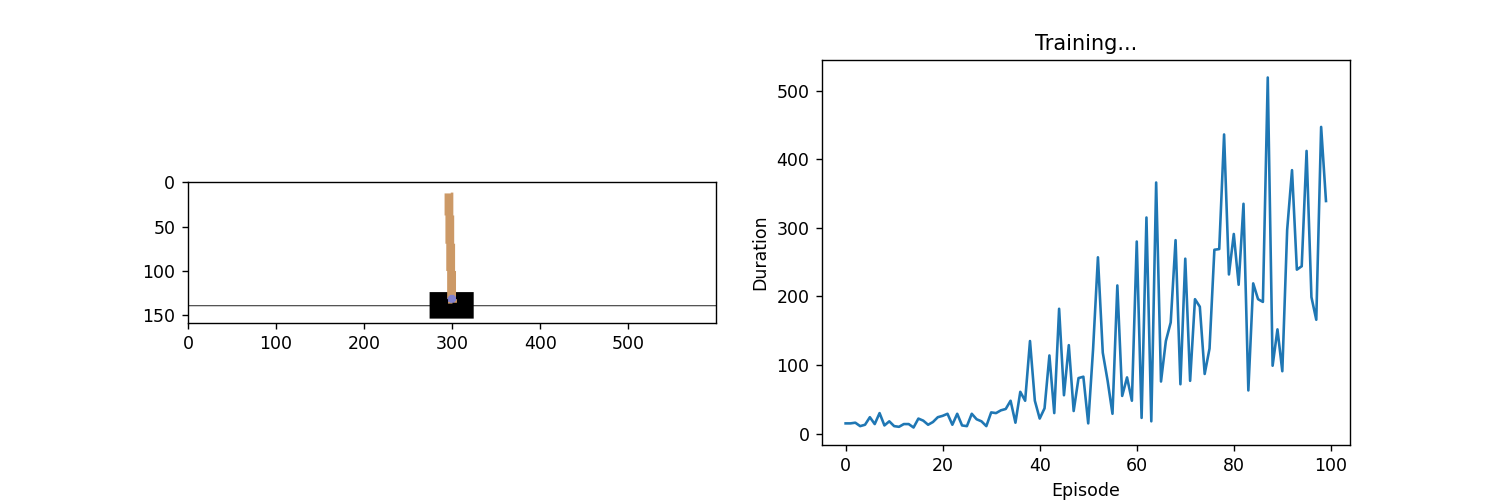

2026-06-21 12:38:37.133100: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1782016718.525297 3015722 service.cc:145] XLA service 0x73fab8005820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782016718.525324 3015722 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-06-21 12:38:38.532571: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782016719.452442 3015722 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Complete
最好成绩： 519


In [9]:
# import warnings
# warnings.filterwarnings('ignore')

plt.ion()
fig1=plt.figure(figsize=(12,4))
ax1_1 = fig1.add_subplot(121)
ax1_2 = fig1.add_subplot(122)
init_screen,rawscreen = get_screen()
ax1_1.imshow(rawscreen)
fig1.canvas.draw()

num_episodes = 100
for i_episode in range(num_episodes):
    # Initialize the environment and state
    env.reset()
    last_screen = init_screen
    current_screen,_ = get_screen()
    state = current_screen - last_screen
    for t in count():
        # Select and perform an action
        action = select_action(state)
        ss, reward, done, _ = env.step(action)
        
        ### ===== reward-shaping策略 =====
        # 利用env.state信息计算边界感知的塑形奖励
        cart_pos, cart_vel, pole_angle, pole_vel = env.state
        
        # 角度比率：0=直立, 1=终止边界(±12°=0.2095rad)
        angle_ratio = abs(pole_angle) / 0.2095
        angle_penalty = -0.5 * (angle_ratio ** 2)
        
        # 位置比率：0=中心, 1=终止边界(±2.4)
        pos_ratio = abs(cart_pos) / 2.4
        pos_penalty = -0.3 * (pos_ratio ** 2)
        
        # 当角度和位置都接近中心时给予小奖励
        center_bonus = 0.1 * (1.0 - angle_ratio) * (1.0 - pos_ratio)
        
        reward = 1.0 + angle_penalty + pos_penalty + center_bonus
        # 防止负奖励导致智能体"自杀"行为
        reward = max(reward, 0.0)
        ### ===== end reward-shaping =====
        
        # Observe new state
        last_screen = current_screen
        current_screen,rawscreen = get_screen()

        ### ===== 以下显示动画已禁用，以提高训练速度 =====
        # ax1_1.clear()
        # if done:
        #     ax1_1.set_title('!!Fail!!')
        # else:
        #     ax1_1.set_title('score:'+str(t+1))
        # ax1_1.imshow(rawscreen)
        # fig1.canvas.draw()
        # plt.pause(0.001)
        ### ===== 以上显示动画已禁用 =====
        
        if not done:
            next_state = current_screen - last_screen
        else:
            next_state = None

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the target network)
        optimize_model()
        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break
    # Update the target network, copying all weights and biases in DQN
    if i_episode % TARGET_UPDATE == 0:
        model_target.set_weights(model.get_weights())

print('Complete')
# env.render()
env.close()
plt.ioff()
plt.show()
print('最好成绩：', max(episode_durations))